# Morlet time-frequency power

## tl;dr

- EEG is resampled to 125 Hz and transformed with zero-mean complex Morlet wavelets on the exact 2-40 Hz grid.
- Cycle counts follow `clip(frequency / 2, 3, 10)`, trading temporal resolution for frequency resolution as frequency increases.
- The longest wavelet determines a common edge trim; the remaining power is averaged over centered 32-sample bins for a 0.256 s time step.
- Synthetic 10 Hz and 25 Hz bursts validate both frequency and timing localization before real `exec` and `patt` blocks are inspected.


## Context and methods

This notebook validates spectral preprocessing checkpoint 5. It demonstrates transform mechanics and artifact contracts; it does not compare recording families statistically and does not define an ML split.

The implementation uses `mne.time_frequency.tfr_array_morlet` with `output="power"`, `zero_mean=True`, `use_fft=True`, and `decim=1`. Decimation is intentionally avoided inside MNE because it occurs after convolution and may alias. Instead, edge-contaminated samples are removed and valid power is averaged in non-overlapping time bins.

Morlet power and FFT/STFT PSD use different normalizations. Their absolute amplitudes must not be compared directly.


### 1. Setup


In [1]:
import json
import os
import sys
from pathlib import Path
from time import perf_counter

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-eeg-morlet")

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from IPython.display import display
from mne.time_frequency import fwhm, morlet


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not find project root")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from preprocessors import (
    MorletConfig,
    build_frequency_grid,
    build_morlet_cycles,
    compute_morlet_power,
    load_preprocessing_config,
)
from utils.datasets import MorletDataset


config = load_preprocessing_config("morlet")
assert isinstance(config, MorletConfig)
frequencies = build_frequency_grid(config)
n_cycles = build_morlet_cycles(frequencies, config)

pd.Series(
    {
        "project_root": str(PROJECT_ROOT),
        "mne_version": mne.__version__,
        "analysis_sfreq_hz": config.analysis_sfreq,
        "frequency_range_hz": f"{config.f_min:g}-{config.f_max:g}",
        "frequency_step_hz": config.frequency_step,
        "cycle_rule": "clip(frequency / 2, 3, 10)",
        "time_bin_samples": config.time_bin_samples,
        "time_step_seconds": config.time_bin_samples / config.analysis_sfreq,
        "output_dtype": config.dtype,
    },
    name="Morlet configuration",
)


project_root          /home/slauva/Projects/master-thesis-2024-2026/...
mne_version                                                      1.11.0
analysis_sfreq_hz                                                 125.0
frequency_range_hz                                                 2-40
frequency_step_hz                                                   1.0
cycle_rule                                   clip(frequency / 2, 3, 10)
time_bin_samples                                                     32
time_step_seconds                                                 0.256
output_dtype                                                    float32
Name: Morlet configuration, dtype: object

## Wavelet geometry

### 2. Inspect cycles, duration, and edge trim

MNE wavelets extend to ±5 standard deviations of the Gaussian envelope and include a sample at zero. A common time axis requires trimming by half the longest actual discrete wavelet at every frequency.


In [2]:
wavelets = morlet(
    sfreq=config.analysis_sfreq,
    freqs=frequencies,
    n_cycles=n_cycles,
    zero_mean=config.zero_mean,
)
wavelet_lengths = np.array([len(wavelet) for wavelet in wavelets])
edge_samples = int(wavelet_lengths.max() // 2)
geometry = pd.DataFrame(
    {
        "frequency_hz": frequencies,
        "n_cycles": n_cycles,
        "wavelet_samples": wavelet_lengths,
        "wavelet_duration_s": wavelet_lengths / config.analysis_sfreq,
        "gaussian_fwhm_s": fwhm(frequencies, n_cycles),
    }
).set_index("frequency_hz")

display(geometry.loc[[2.0, 4.0, 8.0, 10.0, 20.0, 40.0]])
display(
    pd.Series(
        {
            "longest_wavelet_samples": int(wavelet_lengths.max()),
            "edge_trim_samples_per_side": edge_samples,
            "edge_trim_seconds_per_side": edge_samples / config.analysis_sfreq,
        },
        name="Common trim",
    )
)

assert wavelet_lengths.max() == 299
assert edge_samples == 149


,n_cycles,wavelet_samples,wavelet_duration_s,gaussian_fwhm_s
frequency_hz,,,,
2.0,3.0,299,2.392,0.562172
4.0,3.0,149,1.192,0.281086
8.0,4.0,99,0.792,0.187391
10.0,5.0,99,0.792,0.187391
20.0,10.0,99,0.792,0.187391
40.0,10.0,49,0.392,0.093695


longest_wavelet_samples       299.000
edge_trim_samples_per_side    149.000
edge_trim_seconds_per_side      1.192
Name: Common trim, dtype: float64

## Validation

### 3. Synthetic frequency and timing localization

Two Hann-tapered bursts are generated at the corpus source rate: 10 Hz from 2-4 s and 25 Hz from 6-8 s. The expected peak frequency and peak time are checked after 1,000 Hz to 125 Hz resampling, convolution, edge trim, and time binning.


In [3]:
def make_burst(time, *, frequency, start, stop):
    mask = (time >= start) & (time < stop)
    envelope = np.zeros_like(time)
    envelope[mask] = np.hanning(mask.sum())
    return envelope * np.sin(2.0 * np.pi * frequency * time)


source_sfreq = 1_000.0
source_time = np.arange(10_000, dtype=np.float64) / source_sfreq
burst_specs = [
    {"frequency_hz": 10.0, "start_s": 2.0, "stop_s": 4.0},
    {"frequency_hz": 25.0, "start_s": 6.0, "stop_s": 8.0},
]
synthetic_eeg = sum(
    make_burst(
        source_time,
        frequency=spec["frequency_hz"],
        start=spec["start_s"],
        stop=spec["stop_s"],
    )
    for spec in burst_specs
)[np.newaxis, :]

synthetic_result = compute_morlet_power(
    synthetic_eeg,
    source_sfreq=source_sfreq,
    config=config,
)

localization_rows = []
for spec in burst_specs:
    frequency_index = int(np.searchsorted(synthetic_result.frequencies, spec["frequency_hz"]))
    peak_time = float(
        synthetic_result.times[np.argmax(synthetic_result.eeg_power[0, frequency_index])]
    )
    expected_center = (spec["start_s"] + spec["stop_s"]) / 2.0
    center_index = int(np.argmin(np.abs(synthetic_result.times - expected_center)))
    detected_frequency = float(
        synthetic_result.frequencies[np.argmax(synthetic_result.eeg_power[0, :, center_index])]
    )
    localization_rows.append(
        {
            "expected_frequency_hz": spec["frequency_hz"],
            "detected_frequency_hz": detected_frequency,
            "burst_start_s": spec["start_s"],
            "burst_stop_s": spec["stop_s"],
            "detected_peak_time_s": peak_time,
            "absolute_center_error_s": abs(peak_time - expected_center),
        }
    )

localization = pd.DataFrame(localization_rows)
display(localization)

assert synthetic_result.eeg_power.shape == (1, 39, 29)
assert synthetic_result.eeg_power.dtype == np.float32
assert np.allclose(np.diff(synthetic_result.times), 0.256)
assert np.array_equal(localization["detected_frequency_hz"], localization["expected_frequency_hz"])
assert (localization["detected_peak_time_s"] >= localization["burst_start_s"]).all()
assert (localization["detected_peak_time_s"] <= localization["burst_stop_s"]).all()


,expected_frequency_hz,detected_frequency_hz,burst_start_s,burst_stop_s,detected_peak_time_s,absolute_center_error_s
0,10.0,10.0,2.0,4.0,2.948,0.052
1,25.0,25.0,6.0,8.0,7.044,0.044


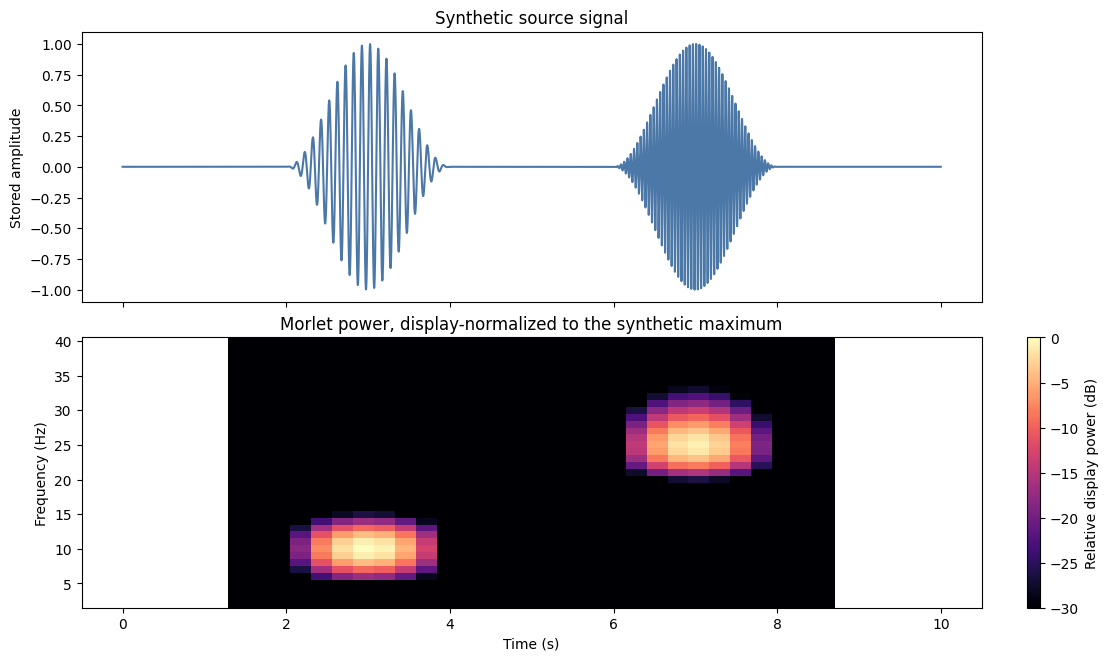

In [4]:
synthetic_display = 10.0 * np.log10(
    np.maximum(synthetic_result.eeg_power[0], np.finfo(np.float32).tiny)
)
synthetic_display -= synthetic_display.max()

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, layout="constrained")
axes[0].plot(source_time, synthetic_eeg[0], color="#4C78A8")
axes[0].set(title="Synthetic source signal", ylabel="Stored amplitude")
mesh = axes[1].pcolormesh(
    synthetic_result.times,
    synthetic_result.frequencies,
    synthetic_display,
    shading="auto",
    cmap="magma",
    vmin=-30,
    vmax=0,
)
axes[1].set(
    title="Morlet power, display-normalized to the synthetic maximum",
    xlabel="Time (s)",
    ylabel="Frequency (Hz)",
)
fig.colorbar(mesh, ax=axes[1], label="Relative display power (dB)")
plt.show()


## Real data

### 4. Transform one `exec` and one `patt` block

The first canonical block in each stable index is used for I/O and contract validation only. Original EOG is retained as source data and is not transformed or duplicated in spectral artifacts.


In [5]:
family_settings = {
    "exec": {
        "dataset_dir": PROJECT_ROOT / "data" / "Data_Train",
        "dataset_step_type": "exec",
    },
    "patt": {
        "dataset_dir": PROJECT_ROOT / "data" / "Data_Pattern",
        "dataset_step_type": "patt",
    },
}

real_datasets = {}
real_samples = {}
real_rows = []
for family, settings in family_settings.items():
    dataset = MorletDataset(**settings, source_cache_policy=None)
    first_start = perf_counter()
    sample = dataset[0]
    first_seconds = perf_counter() - first_start
    cached_start = perf_counter()
    cached_sample = dataset[0]
    cached_seconds = perf_counter() - cached_start

    source = dataset.source_dataset[0]
    cache_entry = dataset.get_cache_entry_path(0)
    cache_bytes = sum(path.stat().st_size for path in cache_entry.iterdir() if path.is_file())
    real_datasets[family] = dataset
    real_samples[family] = sample
    real_rows.append(
        {
            "family": family,
            "key": (
                sample.sample.subject_id,
                sample.sample.trial_number,
                sample.sample.block_index,
            ),
            "source_shape": source.eeg.shape,
            "output_shape": sample.eeg_power.shape,
            "time_start_s": float(sample.times[0]),
            "time_stop_s": float(sample.times[-1]),
            "time_step_s": float(np.median(np.diff(sample.times))),
            "eog_nan_fraction": float(np.isnan(sample.eog).mean()),
            "first_access_seconds": first_seconds,
            "cached_access_seconds": cached_seconds,
            "artifact_kib": cache_bytes / 1024.0,
        }
    )
    np.testing.assert_array_equal(cached_sample.eeg_power, sample.eeg_power)
    np.testing.assert_array_equal(cached_sample.times, sample.times)

real_summary = pd.DataFrame(real_rows).set_index("family")
display(real_summary)

assert real_samples["exec"].eeg_power.shape == (63, 39, 53)
assert real_samples["patt"].eeg_power.shape == (63, 39, 92)
for family, sample in real_samples.items():
    assert sample.eeg_power.dtype == np.float32, family
    assert sample.times.dtype == np.float32, family
    assert np.isfinite(sample.eeg_power).all(), family
    assert np.all(sample.eeg_power >= 0), family
    assert np.allclose(np.diff(sample.times), 0.256), family


,key,source_shape,output_shape,time_start_s,time_stop_s,time_step_s,eog_nan_fraction,first_access_seconds,cached_access_seconds,artifact_kib
family,,,,,,,,,,
exec,"(1, 1, 1)","(63, 16001)","(63, 39, 53)",1.340,14.652000,0.256,0.000000,0.141409,0.008006,511.621094
patt,"(1, 1, 1)","(63, 26001)","(63, 39, 92)",1.348,24.643999,0.256,0.057059,0.199258,0.010528,886.085938


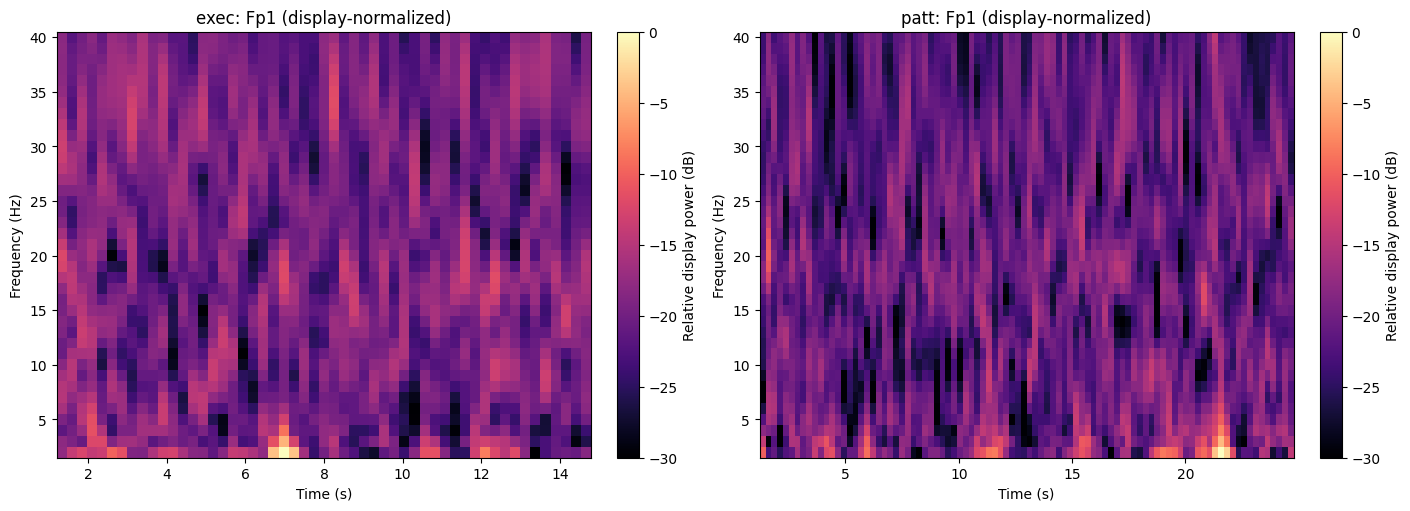

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), layout="constrained")
for ax, (family, sample) in zip(axes, real_samples.items(), strict=True):
    channel_power = sample.eeg_power[0]
    display_power = 10.0 * np.log10(np.maximum(channel_power, np.finfo(np.float32).tiny))
    display_power -= display_power.max()
    mesh = ax.pcolormesh(
        sample.times,
        sample.frequencies,
        display_power,
        shading="auto",
        cmap="magma",
        vmin=-30,
        vmax=0,
    )
    ax.set(
        title=f"{family}: {sample.eeg_channels[0]} (display-normalized)",
        xlabel="Time (s)",
        ylabel="Frequency (Hz)",
    )
    fig.colorbar(mesh, ax=ax, label="Relative display power (dB)")
plt.show()


### 5. Inspect cache manifests

Morlet entries store `eeg_power.npy`, `frequencies.npy`, `times.npy`, and the manifest. The display-normalized dB arrays above are never written to artifacts.


In [7]:
manifest_rows = []
for family, dataset in real_datasets.items():
    entry = dataset.get_cache_entry_path(0)
    manifest = json.loads((entry / "manifest.json").read_text(encoding="utf-8"))
    files = sorted(path.name for path in entry.iterdir() if path.is_file())
    manifest_rows.append(
        {
            "family": family,
            "config_hash": manifest["config_hash"],
            "files": files,
            "power_shape": tuple(manifest["arrays"]["eeg_power"]["shape"]),
            "times_shape": tuple(manifest["arrays"]["times"]["shape"]),
            "power_dtype": manifest["arrays"]["eeg_power"]["dtype"],
            "sources": sorted(manifest["sources"]),
        }
    )
    assert files == ["eeg_power.npy", "frequencies.npy", "manifest.json", "times.npy"]

display(pd.DataFrame(manifest_rows).set_index("family"))


,config_hash,files,power_shape,times_shape,power_dtype,sources
family,,,,,,
exec,2bd6a0d2308da234,"[eeg_power.npy, frequencies.npy, manifest.json...","(63, 39, 53)","(53,)",float32,"[eeg, eog]"
patt,2bd6a0d2308da234,"[eeg_power.npy, frequencies.npy, manifest.json...","(63, 39, 92)","(92,)",float32,"[eeg, eog]"


## Takeaways

1. The configured cycle rule yields a 299-sample longest wavelet and a 149-sample trim on each side at 125 Hz.
2. Synthetic 10 Hz and 25 Hz bursts are localized correctly in both frequency and time after resampling, convolution, trimming, and 0.256 s binning.
3. Real `exec` and `patt` blocks produce finite non-negative `float32` wavelet-power arrays with actual per-block time axes.
4. Display normalization is limited to plotting; cached arrays retain native Morlet power.
5. These examples validate mechanics only and do not support condition, subject, or prediction claims.
